In [1]:
from sedona.spark import SedonaContext
import os

In [2]:
!aws s3 cp s3://ptokaj-sedona-book/source_data/vietnam_roads ./ --recursive

download: s3://ptokaj-sedona-book/source_data/vietnam_roads/gis_osm_roads_free_1.cpg to ./gis_osm_roads_free_1.cpg
download: s3://ptokaj-sedona-book/source_data/vietnam_roads/gis_osm_roads_free_1.prj to ./gis_osm_roads_free_1.prj
download: s3://ptokaj-sedona-book/source_data/vietnam_roads/gis_osm_roads_free_1.shx to ./gis_osm_roads_free_1.shx
download: s3://ptokaj-sedona-book/source_data/vietnam_roads/gis_osm_roads_free_1.dbf to ./gis_osm_roads_free_1.dbf
download: s3://ptokaj-sedona-book/source_data/vietnam_roads/gis_osm_roads_free_1.shp to ./gis_osm_roads_free_1.shp


In [2]:
%%capture
bucket_name = os.environ.get("SEDONA_SOURCE_BUCKET", "apache-sedona-book")

config = SedonaContext.builder()

sedona = SedonaContext.create(config.getOrCreate())

sedona.sparkContext.setLogLevel("ERROR")

sc = sedona.sparkContext

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/08/22 22:04:30 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/08/22 22:04:32 WARN UDTRegistration: Cannot register UDT for org.geotools.coverage.grid.GridCoverage2D, which is already registered.
25/08/22 22:04:32 WARN SimpleFunctionRegistry: The function rs_union_aggr replaced a previously registered function.
25/08/22 22:04:32 WARN UDTRegistration: Cannot register UDT for org.locationtech.jts.geom.Geometry, which is already registered.
25/08/22 22:04:32 WARN UDTRegistration: Cannot register UDT for org.apache.sedona.common.S2Geography.Geography, which is already registered.
25/08/22 22:04:32 WARN UDTRegistration: Cannot register UDT for org.locationtech.jts.index.SpatialIndex, which is already registered.
25/08/22 22:04:32 WARN SimpleFunctionRegistry: The function st_envelop

# Geometry constructors

In [3]:
sedona.sql(
    """
    SELECT ST_GeomFromText('POINT (151.241012 -33.843705)') AS geom
    """
).show()

+--------------------+
|                geom|
+--------------------+
|POINT (151.241012...|
+--------------------+



In [4]:
sedona.sql(
    """
    SELECT ST_GeomFromText('POINT (151.241012 -33.843705)') AS geom
        
    """
).createOrReplaceTempView("points")

# Geometry functions

In [5]:
sedona.sql(
    """
    SELECT 
        ST_GeometryType(geom) AS geom_type
    FROM points
        
    """
).show()

+---------+
|geom_type|
+---------+
| ST_Point|
+---------+



In [6]:
sedona.sql(
    """
    SELECT 
        ST_SRID(geom) AS srid
    FROM points
    """
).show()

+----+
|srid|
+----+
|   0|
+----+



In [7]:
sedona.sql(
    """
    SELECT 
        ST_Transform(ST_SetSRID(geom, 4326), 'EPSG:3857') AS geom
    FROM points
    """
).show(1, False)

+---------------------------------------------+
|geom                                         |
+---------------------------------------------+
|POINT (16836072.44289938 -4007834.6839636774)|
+---------------------------------------------+



In [8]:
sedona.sql(
    """
    SELECT 
        ST_SRID(ST_Transform(ST_SetSRID(geom, 4326), 'EPSG:3857')) AS geom
    FROM points
    """
).show(1, False)

+----+
|geom|
+----+
|3857|
+----+



# Transforming Vietnam road Data

In [10]:
!ls

SpatialSQLAndVectorManipulation.ipynb  gis_osm_roads_free_1.prj
apply.sh			       gis_osm_roads_free_1.shp
aws				       gis_osm_roads_free_1.shx
aws-java-sdk-bundle-1.12.262.jar       hadoop-aws-3.3.4.jar
awscliv2.zip			       mysql-connector-j-9.4.0.jar
examples			       postgresql-42.7.4.jar
geotools-wrapper-1.7.2-28.5.jar        s3-conf.conf
gis_osm_roads_free_1.cpg	       sedona-spark-shaded-3.5_2.12-1.7.2.jar
gis_osm_roads_free_1.dbf


In [9]:
roads = sedona.\
    read.\
    format("shapefile").\
    load(f"gis_osm_roads_free_1.shp")

roads.createOrReplaceTempView("roads")

# Preparing data for routing dataset, using the ST_StartPoint and ST_EndPoint function

In [10]:
sedona.sql(
"""
    SELECT 
        osm_id as id,
        ST_StartPoint(geometry) AS geom
    FROM roads
    UNION ALL
    SELECT 
        osm_id as id,
        ST_EndPoint(geometry) AS geom
    FROM roads
"""    
).show()

+--------+--------------------+
|      id|                geom|
+--------+--------------------+
| 9566542|POINT (105.852999...|
| 9656653|POINT (105.853446...|
| 9656730|POINT (105.865640...|
| 9963509|POINT (105.847163...|
| 9964440|POINT (105.838099...|
| 9964551|POINT (105.82426 ...|
| 9964663|POINT (105.842177...|
| 9965723|POINT (105.853230...|
| 9975059|POINT (105.888769...|
| 9978719|POINT (105.893973...|
|10045075|POINT (105.801391...|
|10046571|POINT (105.798351...|
|10047796|POINT (105.778322...|
|10047852|POINT (105.841426...|
|10047949|POINT (105.845505...|
|10048048|POINT (105.843671...|
|10048345|POINT (105.778322...|
|10049443|POINT (105.810260...|
|10049446|POINT (105.818639...|
|10230410|POINT (105.855307...|
+--------+--------------------+
only showing top 20 rows



# Finding roads to block before marathon using the ST_ConvexHull function

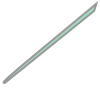

In [11]:
sedona.sql(
    """
    SELECT 
        ST_ConvexHull(ST_Union_Aggr(geometry))
    FROM roads 
    WHERE name = 'Phố Giảng Võ' or name = 'Phố Kim Mã' and fclass = 'primary'
    """
    
).collect()[0][0]

In [12]:
sedona.sql(
    """
    SELECT ST_ConvexHull(ST_Union_Aggr(geometry)) AS geom
    FROM roads where name = 'Phố Giảng Võ' or name = 'Phố Kim Mã' and fclass = 'primary'
    """
    
).createOrReplaceTempView("convex_hull")

In [13]:
sedona.sql(
    """
    SELECT DISTINCT name
    FROM roads
    WHERE ST_Intersects(geometry, (
        SELECT
            ST_Transform(
                ST_Buffer(
                    ST_Transform(geom, 'EPSG:3405'),
                    500
                ),
                'EPSG:4326'
            ) as geom
        FROM convex_hull
    ))
    """
).show()

[Stage 16:>                                                         (0 + 1) / 1]

+--------------------+
|                name|
+--------------------+
|     Ngõ 152 Hào Nam|
|  Ngõ 94 Phố Ngọc Hà|
|Ngõ 71 Lê Hồng Phong|
|Ngách 51 Ngõ 158 ...|
|      Ngõ Quan Thổ 1|
|       Phố Hàng Cháo|
|      Ngõ 32 Sơn Tây|
|   Ngõ 20 Thành Công|
| Ngõ 8B Phố Vũ Thạnh|
|Ngõ 156 Mai Anh Tuấn|
|        Phố Bích Câu|
|      Ngõ An Trạch 1|
|Ngách 6 Ngõ 189 G...|
|         Phố Đội Cấn|
|     Ngõ 104 Đội Cấn|
|    Ngõ 20A Núi Trúc|
|Ngách 1 Ngõ 2 Vũ ...|
|     Ngõ 12 Cát Linh|
|    Ngõ 149 Giảng Võ|
|       Ngõ Hàng Cháo|
+--------------------+
only showing top 20 rows



In [14]:
sedona.sql(
    """
    SELECT DISTINCT name
    FROM roads
    WHERE ST_DWithin(geometry, (SELECT geom FROM convex_hull), 500, true)
    """
).show()

[Stage 22:>                                                         (0 + 1) / 1]

+--------------------+
|                name|
+--------------------+
|     Ngõ 152 Hào Nam|
| Ngõ 8B Phố Vũ Thạnh|
|      Ngõ An Trạch 1|
|Ngách 6 Ngõ 189 G...|
|    Ngõ 20A Núi Trúc|
|Ngách 1 Ngõ 2 Vũ ...|
|    Ngõ 149 Giảng Võ|
|     Ngõ 127 Hào Nam|
|     Ngõ 29 Vũ Thạnh|
|    Ngõ 187 Giảng Võ|
|Ngách 99 Ngõ 318 ...|
|Ngách 48 Ngõ 29 V...|
|      Ngõ 125 Kim Mã|
|Ngách 22 Ngõ 169 ...|
|  Phố Giang Văn Minh|
|Ngõ 23 Giang Văn ...|
|         Phố Nam Cao|
|     Ngõ 167 Hào Nam|
|     Ngõ 95 Giảng Võ|
|     Ngõ 33 Cát Linh|
+--------------------+
only showing top 20 rows

